# Simple Linear Regression

## When will the food arrive?

A delivery time includes a starting wait and time spent traveling. A straight line represents this with two adjustable numbers. The delivery records in this example are synthetic.

> Predicted delivery time = starting wait + travel time for the route

The intercept sets the starting wait. The slope sets the additional minutes per kilometre. Moving either changes every prediction. These are model coefficients, estimated from previous deliveries.

<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/06-1_Regression/assets/02_residuals_and_squared_error.png" alt="Recorded and predicted delivery times with vertical gaps showing early and late arrivals." width="640" style="max-width:100%;height:auto;">

A residual is the recorded time minus the predicted time. A dot above the line represents a later arrival than predicted. Ordinary least squares, or OLS, fits a line by minimizing squared residuals. Squaring prevents early and late errors from cancelling and gives large misses more influence.


## A promise that is too optimistic

The starting-wait and travel-time controls move the line through 16 delivery records. Filled dots show arrivals; open dots show predictions for the same routes. Vertical gaps connect the two.

`OLS fit` applies the best-fitting line. The typical miss is MAE, the average size of the gaps in minutes. RMSE is another error score in minutes that gives large misses more influence. Neither score is an accuracy percentage.


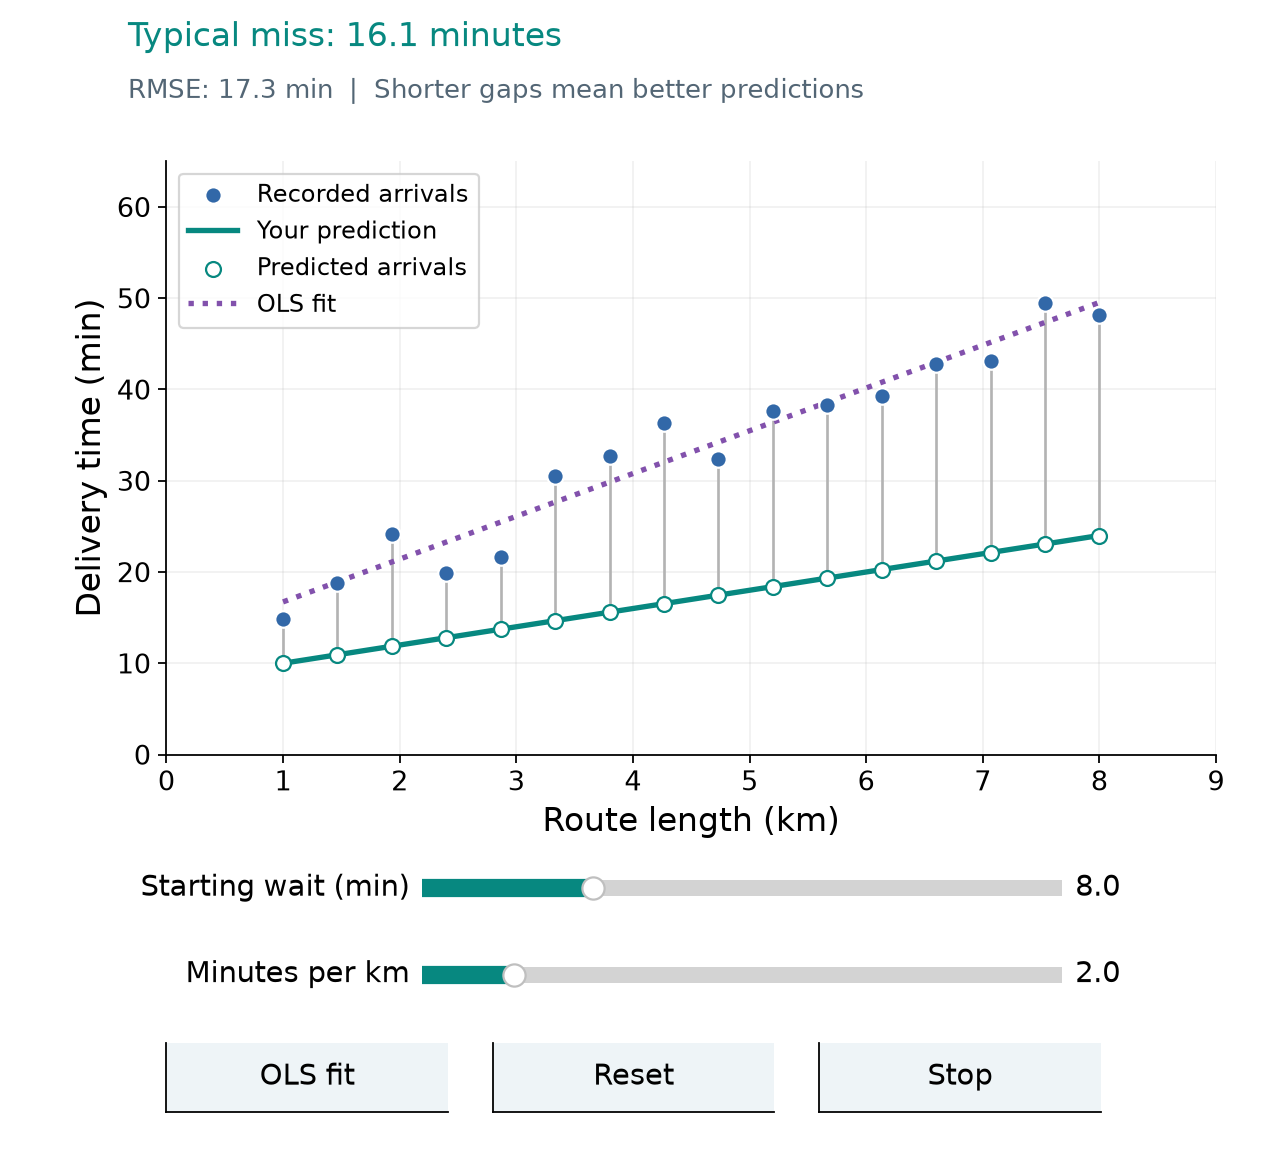

In [1]:
import os
import sys
import io
import numpy as np
import pandas as pd
import matplotlib

REGRESSION_STATIC = os.environ.get("REGRESSION_STATIC") == "1"
REGRESSION_BROWSER = sys.platform == "emscripten"
if not REGRESSION_STATIC and not REGRESSION_BROWSER:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, "kernel", None) is not None:
        shell.run_line_magic("matplotlib", "widget")

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle
from IPython.display import Image, display
from sklearn.linear_model import LinearRegression

plt.rcParams.update({
    "font.size": 15, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "lines.linewidth": 2.4,
    "axes.unicode_minus": False, "figure.facecolor": "white",
})
BLUE, TEAL, ORANGE, PURPLE = "#3268a8", "#078880", "#d87522", "#8251ac"


def metrics(observed, predicted):
    """R² is undefined for a constant evaluation target."""
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = observed - predicted
    mse = np.mean(error**2)
    total = np.sum((observed - observed.mean())**2)
    return {"MAE": np.mean(np.abs(error)), "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R²": 1 - np.sum(error**2) / total if total > 0 else np.nan}


# Close earlier views before replacing models or shared callbacks on a rerun.
for _previous_view in globals().get("_regression_views", {}).values():
    _previous_view.close()
_regression_views = {}


class RegressionExplorer:
    """Sliders redraw the model and its metrics from the same observations."""

    def __init__(self, name, render, sliders, actions=(), history=False):
        previous = _regression_views.get(name)
        if previous is not None:
            previous.close()
        self.render = render
        self.running = False
        self.controls, self.buttons, self.state = {}, {}, {}
        self.defaults = {key: initial for key, label, low, high, initial, step, fmt in sliders}
        # 80 dpi gives a 640 px live canvas; saved output uses 160 dpi at the same display size.
        with plt.ioff():
            self.figure = plt.figure(figsize=(8, 8.4 if history else 7.2), dpi=80)
        self.status = self.figure.text(.10, .96, "", fontsize=15, color=TEAL)
        self.detail = self.figure.text(.10, .915, "", fontsize=11.5, color="#536675")
        bottom = .27 + .075 * (len(sliders) - 1)
        if history:
            self.ax = self.figure.add_axes([.13, .56, .82, .30])
            self.history_ax = self.figure.add_axes([.13, .33, .82, .12])
        else:
            self.ax = self.figure.add_axes([.13, bottom, .82, .86 - bottom])
        for i, (key, label, low, high, initial, step, fmt) in enumerate(sliders):
            y = .14 + .075 * (len(sliders) - i - 1)
            slider = Slider(self.figure.add_axes([.33, y, .50, .028]),
                            label, low, high, valinit=initial, valstep=step,
                            valfmt=fmt, color=TEAL)
            slider.label.set_fontsize(13)
            slider.valtext.set_fontsize(13)
            slider.on_changed(self.update)
            self.controls[key] = slider
        commands = list(actions) + [("Reset", lambda view: view.reset()),
                                    ("Stop", lambda view: view.stop())]
        width = min(.22, .8 / len(commands) - .025)
        for i, (label, callback) in enumerate(commands):
            button = Button(self.figure.add_axes([.13 + i*(width+.035), .035, width, .06]),
                            label, color="#eef4f7", hovercolor="#d7e9e6")
            button.label.set_fontsize(13)
            button.on_clicked(lambda event, callback=callback: callback(self))
            self.buttons[label] = button
        self.figure.canvas.mpl_connect("close_event", lambda event: self.stop())
        _regression_views[name] = self
        self.update()

    def update(self, _=None):
        self.ax.clear()
        if hasattr(self, "history_ax"):
            self.history_ax.clear()
        values = {key: slider.val for key, slider in self.controls.items()}
        self.state = self.render(self, **values)
        self.figure.canvas.draw_idle()

    def set_values(self, **values):
        for key, value in values.items():
            slider = self.controls[key]
            events, drawing = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = events, drawing
        self.update()

    def reset(self):
        self.set_values(**self.defaults)

    def start(self):
        if REGRESSION_STATIC:
            buffer = io.BytesIO()
            self.figure.savefig(buffer, format="png", dpi=160, facecolor="white")
            display(Image(data=buffer.getvalue(), width=640,
                          alt=self.status.get_text() + ". " + self.detail.get_text()))
            plt.close(self.figure)
            return
        self.running = True
        if REGRESSION_BROWSER:
            # The browser dispatches input after the cell returns.
            plt.show(block=False)
        elif hasattr(self.figure.canvas, "toolbar_visible"):
            self.figure.canvas.toolbar_visible = False
            self.figure.canvas.header_visible = False
            self.figure.canvas.footer_visible = False
            self.figure.canvas.resizable = False
            display(self.figure.canvas)
        else:
            plt.show(block=False)

    def stop(self):
        self.running = False
        for slider in self.controls.values():
            slider.set_active(False)
        for button in self.buttons.values():
            button.set_active(False)
        self.buttons["Stop"].label.set_text("Stopped")
        self.figure.canvas.draw_idle()

    def close(self):
        self.stop()
        plt.close(self.figure)

rng_delivery = np.random.default_rng(60)
route_train = np.linspace(1, 8, 16)
train_noise = rng_delivery.standard_normal(len(route_train))


def delivery_mean(distance):
    return 14 + 4 * np.asarray(distance)


delivery_train = delivery_mean(route_train) + 3 * train_noise
delivery_model = LinearRegression().fit(route_train[:, None], delivery_train)
intercept, slope = float(delivery_model.intercept_), float(delivery_model.coef_[0])
fitted_delivery = delivery_model.predict(route_train[:, None])


def delivery_axes(ax, high=12):
    ax.set(xlabel="Route length (km)", ylabel="Delivery time (min)", xlim=(0, high))
    ax.legend(loc="upper left")


def render_delivery_fit(view, starting_wait, travel_rate):
    predicted = starting_wait + travel_rate * route_train
    result = metrics(delivery_train, predicted)
    ax = view.ax
    ax.vlines(route_train, predicted, delivery_train, color=".7", linewidth=1.2)
    ax.scatter(route_train, delivery_train, color=BLUE, edgecolor="white", s=55,
               label="Recorded arrivals", zorder=4)
    ax.plot(route_train, predicted, color=TEAL, label="Your prediction")
    ax.scatter(route_train, predicted, facecolors="white", edgecolors=TEAL,
               s=45, zorder=5, label="Predicted arrivals")
    ax.plot(route_train, fitted_delivery, ":", color=PURPLE, label="OLS fit")
    delivery_axes(ax, 9)
    ax.set_ylim(0, max(65, float(predicted.max())+8))
    view.status.set_text(f"Typical miss: {result['MAE']:.1f} minutes")
    view.detail.set_text(f"RMSE: {result['RMSE']:.1f} min  |  Shorter gaps mean better predictions")
    return {"prediction": predicted, "metrics": result}


delivery_fit_demo = RegressionExplorer("delivery_fit", render_delivery_fit, [
    ("starting_wait", "Starting wait (min)", 0, 30, 8, .5, "%0.1f"),
    ("travel_rate", "Minutes per km", 1, 8, 2, .1, "%0.1f"),
], actions=[("OLS fit", lambda view: view.set_values(starting_wait=intercept, travel_rate=slope))])
delivery_fit_demo.start()


## What the line leaves out

A straight line is useful when the average change is roughly steady. Traffic and restaurant delays still vary around that trend. An unusually late order can pull an OLS fit toward it because squaring gives large residuals more influence.

The displayed errors measure the fit to these records. Separate test deliveries are needed to evaluate new predictions. Extrapolation beyond the recorded routes is less supported: a longer route may involve roads and traffic that the model has never observed.
